# Employee Attrition Prediction


Libraries imported successfully!

First 5 Records
   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   ...  RelationshipSati

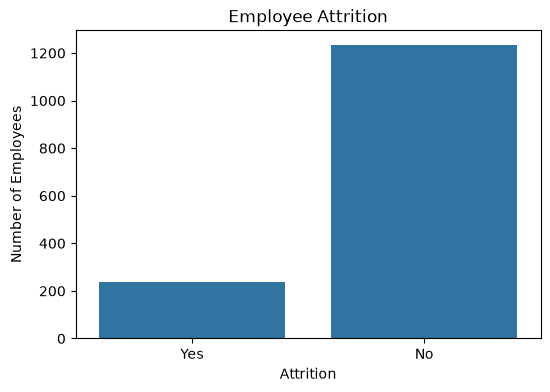

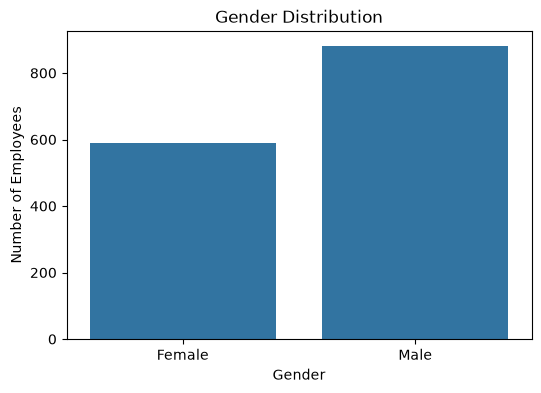

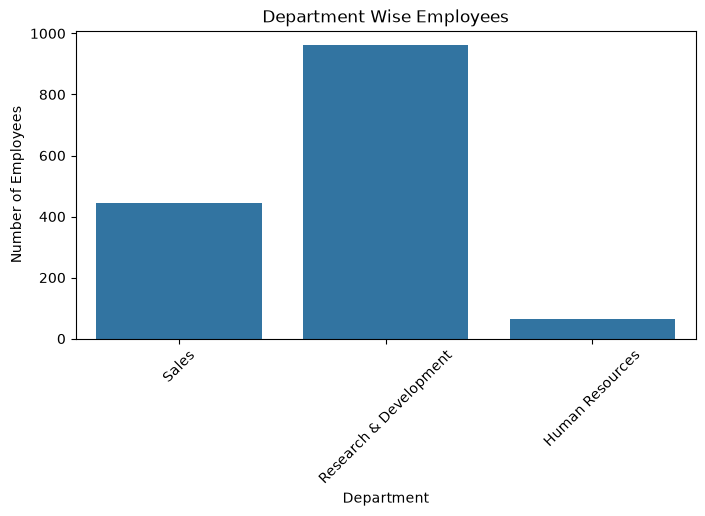

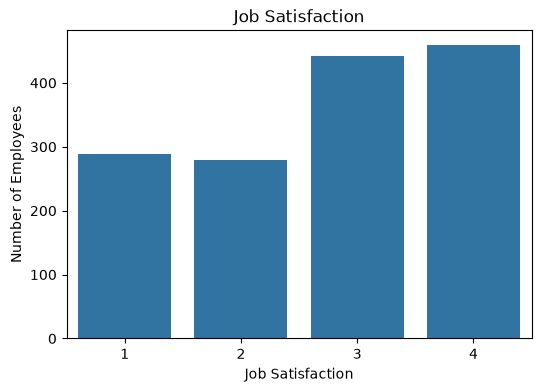

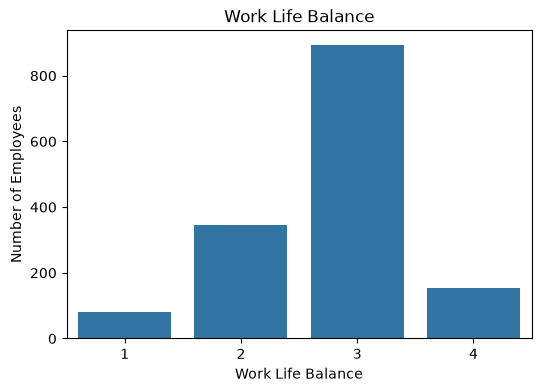

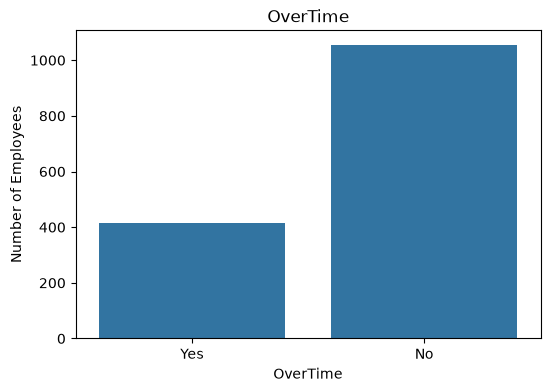

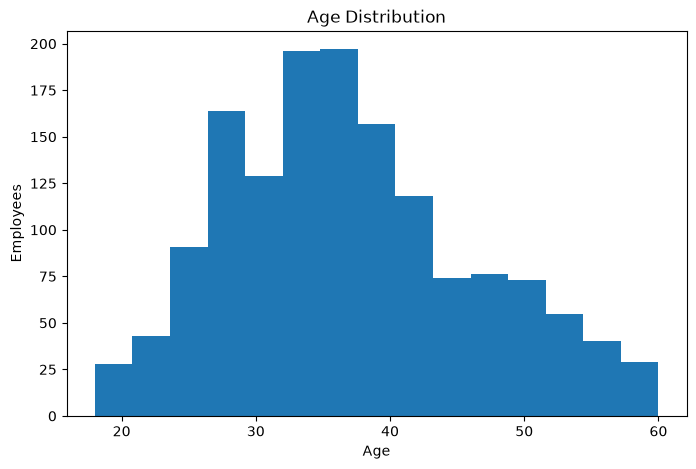

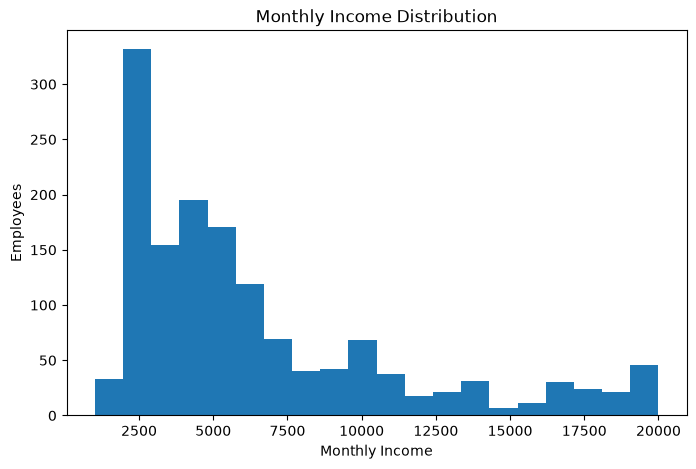


Categorical columns encoded successfully!


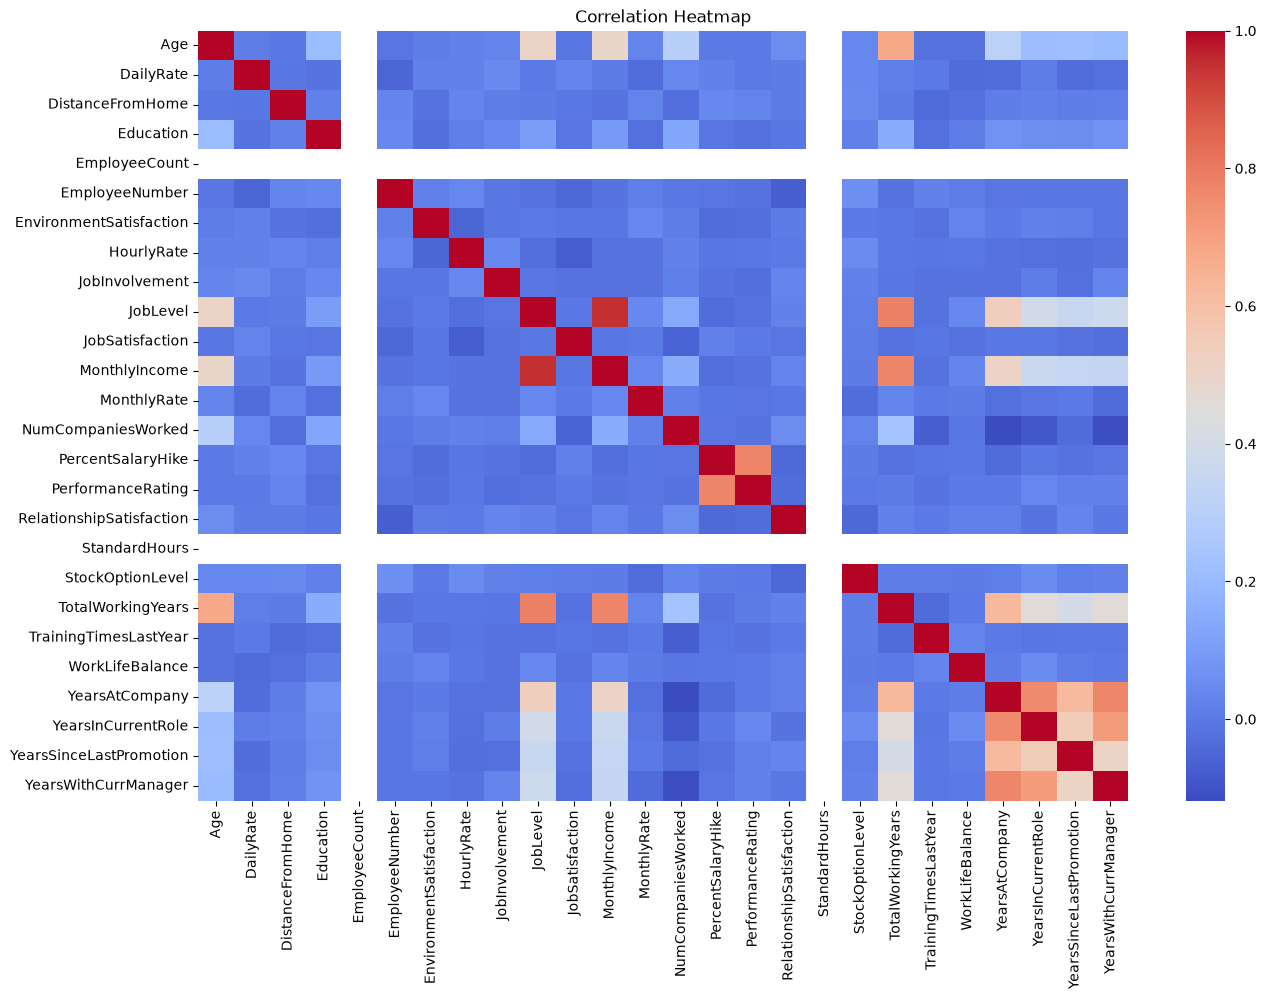


All categorical columns converted to numbers!
Number of Features: 34
Number of Records: 1470

Data Types After Encoding:
Age                         int64
BusinessTravel              int64
DailyRate                   int64
Department                  int64
DistanceFromHome            int64
Education                   int64
EducationField              int64
EmployeeCount               int64
EmployeeNumber              int64
EnvironmentSatisfaction     int64
Gender                      int64
HourlyRate                  int64
JobInvolvement              int64
JobLevel                    int64
JobRole                     int64
JobSatisfaction             int64
MaritalStatus               int64
MonthlyIncome               int64
MonthlyRate                 int64
NumCompaniesWorked          int64
Over18                      int64
OverTime                    int64
PercentSalaryHike           int64
PerformanceRating           int64
RelationshipSatisfaction    int64
StandardHours               

<Figure size 600x500 with 0 Axes>

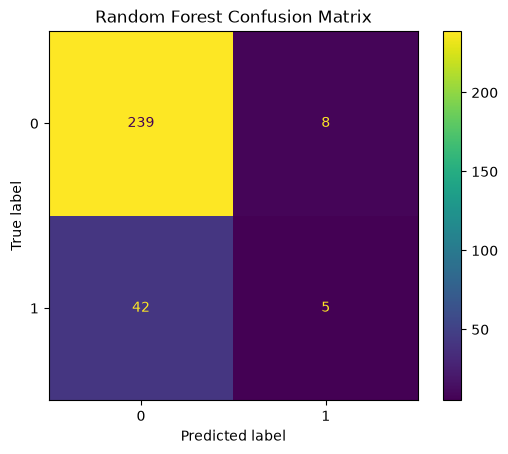


ROC-AUC SCORE
ROC-AUC: 0.8032991644413817


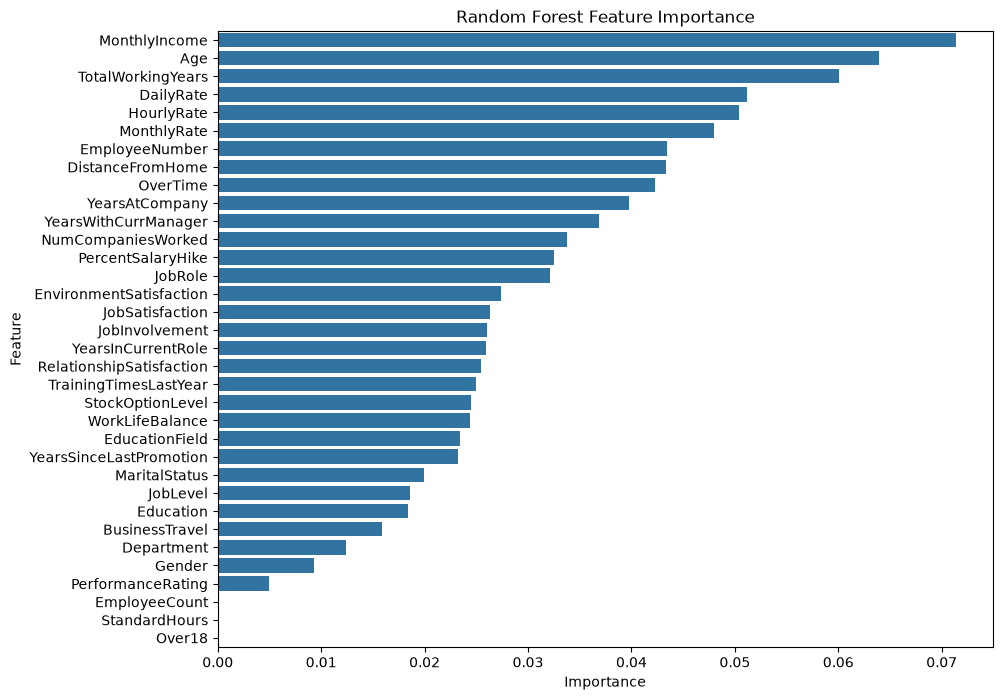


SAMPLE PREDICTION
Employee is likely to leave the company.

FINAL RANDOM FOREST PERFORMANCE
Accuracy : 0.8299319727891157
Precision: 0.38461538461538464
Recall   : 0.10638297872340426
F1 Score : 0.16666666666666666
ROC-AUC  : 0.8032991644413817

FLASK MODEL PERFORMANCE
Accuracy: 0.7925170068027211

MODEL SAVED SUCCESSFULLY
File: attrition_model.pkl
Flask Features: ['Age', 'MonthlyIncome', 'YearsAtCompany', 'JobSatisfaction']

EMPLOYEE ATTRITION PROJECT COMPLETED


In [7]:
# ============================================================
# EMPLOYEE ATTRITION PREDICTION USING MACHINE LEARNING
# ============================================================

# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    ConfusionMatrixDisplay
)

print("Libraries imported successfully!")


# ============================================================
# 2. LOAD DATASET
# ============================================================

df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

print("\nFirst 5 Records")
print(df.head())

print("\nDataset Shape")
print(df.shape)

print("\nDataset Information")
df.info()

print("\nStatistical Summary")
print(df.describe())

print("\nMissing Values")
print(df.isnull().sum())


# ============================================================
# 3. CHECK DUPLICATES
# ============================================================

print("\nDuplicate Rows")
print(df.duplicated().sum())


# ============================================================
# 4. EXPLORATORY DATA ANALYSIS
# ============================================================

# Attrition
plt.figure(figsize=(6, 4))
sns.countplot(x="Attrition", data=df)
plt.title("Employee Attrition")
plt.xlabel("Attrition")
plt.ylabel("Number of Employees")
plt.show()


# Gender
plt.figure(figsize=(6, 4))
sns.countplot(x="Gender", data=df)
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Employees")
plt.show()


# Department
plt.figure(figsize=(8, 4))
sns.countplot(x="Department", data=df)
plt.title("Department Wise Employees")
plt.xlabel("Department")
plt.ylabel("Number of Employees")
plt.xticks(rotation=45)
plt.show()


# Job Satisfaction
plt.figure(figsize=(6, 4))
sns.countplot(x="JobSatisfaction", data=df)
plt.title("Job Satisfaction")
plt.xlabel("Job Satisfaction")
plt.ylabel("Number of Employees")
plt.show()


# Work Life Balance
plt.figure(figsize=(6, 4))
sns.countplot(x="WorkLifeBalance", data=df)
plt.title("Work Life Balance")
plt.xlabel("Work Life Balance")
plt.ylabel("Number of Employees")
plt.show()


# Overtime
plt.figure(figsize=(6, 4))
sns.countplot(x="OverTime", data=df)
plt.title("OverTime")
plt.xlabel("OverTime")
plt.ylabel("Number of Employees")
plt.show()


# Age Distribution
plt.figure(figsize=(8, 5))
plt.hist(df["Age"], bins=15)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Employees")
plt.show()


# Monthly Income Distribution
plt.figure(figsize=(8, 5))
plt.hist(df["MonthlyIncome"], bins=20)
plt.title("Monthly Income Distribution")
plt.xlabel("Monthly Income")
plt.ylabel("Employees")
plt.show()


# ============================================================
# 5. DATA PREPROCESSING
# ============================================================

# Create separate dataframe for Machine Learning
df_ml = df.copy()

# Dictionary to store encoders
label_encoders = {}

# Encode categorical columns
for column in df_ml.columns:

    if df_ml[column].dtype == "object":

        encoder = LabelEncoder()

        df_ml[column] = encoder.fit_transform(
            df_ml[column].astype(str)
        )

        label_encoders[column] = encoder


print("\nCategorical columns encoded successfully!")


# ============================================================
# 6. CORRELATION HEATMAP
# ============================================================

plt.figure(figsize=(15, 10))

correlation = df_ml.corr(numeric_only=True)

sns.heatmap(
    correlation,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

# ============================================================
# 7. FEATURE SELECTION AND ENCODING
# ============================================================

# Create a fresh copy of the original dataset
df_ml = df.copy()

# Convert EVERY non-numeric column into numbers
for column in df_ml.columns:
    if not pd.api.types.is_numeric_dtype(df_ml[column]):
        encoder = LabelEncoder()
        df_ml[column] = encoder.fit_transform(
            df_ml[column].astype(str)
        )

print("\nAll categorical columns converted to numbers!")

# Separate input features and target
X = df_ml.drop("Attrition", axis=1)
y = df_ml["Attrition"]

print("Number of Features:", X.shape[1])
print("Number of Records:", X.shape[0])

# Check data types
print("\nData Types After Encoding:")
print(X.dtypes)

# Check whether any text columns are still present
non_numeric_columns = X.select_dtypes(
    exclude=["number"]
).columns.tolist()

print("\nRemaining Non-Numeric Columns:")
print(non_numeric_columns)

# Stop if any text column remains
if len(non_numeric_columns) > 0:
    raise ValueError(
        "Some columns are still non-numeric: "
        + str(non_numeric_columns)
    )

print("\nSUCCESS: All features are numeric!")


# ============================================================
# 8. TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)


# ============================================================
# 9. FEATURE SCALING
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("\nFeature scaling completed successfully!")

# ============================================================
# 10. LOGISTIC REGRESSION
# ============================================================

lr = LogisticRegression(
    max_iter=5000,
    random_state=42
)

lr.fit(
    X_train_scaled,
    y_train
)

pred_lr = lr.predict(X_test_scaled)

print("\n==============================")
print("LOGISTIC REGRESSION")
print("==============================")

print(
    "Accuracy :",
    accuracy_score(y_test, pred_lr)
)

print(
    "Precision:",
    precision_score(
        y_test,
        pred_lr,
        zero_division=0
    )
)

print(
    "Recall   :",
    recall_score(
        y_test,
        pred_lr,
        zero_division=0
    )
)

print(
    "F1 Score :",
    f1_score(
        y_test,
        pred_lr,
        zero_division=0
    )
)


# ============================================================
# 11. DECISION TREE
# ============================================================

dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(
    X_train_scaled,
    y_train
)

pred_dt = dt.predict(X_test_scaled)

print("\n==============================")
print("DECISION TREE")
print("==============================")

print(
    "Accuracy :",
    accuracy_score(y_test, pred_dt)
)

print(
    "Precision:",
    precision_score(
        y_test,
        pred_dt,
        zero_division=0
    )
)

print(
    "Recall   :",
    recall_score(
        y_test,
        pred_dt,
        zero_division=0
    )
)

print(
    "F1 Score :",
    f1_score(
        y_test,
        pred_dt,
        zero_division=0
    )
)


# ============================================================
# 12. RANDOM FOREST
# ============================================================

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(
    X_train_scaled,
    y_train
)

pred_rf = rf.predict(X_test_scaled)

print("\n==============================")
print("RANDOM FOREST")
print("==============================")

print(
    "Accuracy :",
    accuracy_score(y_test, pred_rf)
)

print(
    "Precision:",
    precision_score(
        y_test,
        pred_rf,
        zero_division=0
    )
)

print(
    "Recall   :",
    recall_score(
        y_test,
        pred_rf,
        zero_division=0
    )
)

print(
    "F1 Score :",
    f1_score(
        y_test,
        pred_rf,
        zero_division=0
    )
)


# ============================================================
# 13. XGBOOST
# ============================================================

xgb = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    eval_metric="logloss",
    random_state=42
)

xgb.fit(
    X_train_scaled,
    y_train
)

pred_xgb = xgb.predict(X_test_scaled)

print("\n==============================")
print("XGBOOST")
print("==============================")

print(
    "Accuracy :",
    accuracy_score(y_test, pred_xgb)
)

print(
    "Precision:",
    precision_score(
        y_test,
        pred_xgb,
        zero_division=0
    )
)

print(
    "Recall   :",
    recall_score(
        y_test,
        pred_xgb,
        zero_division=0
    )
)

print(
    "F1 Score :",
    f1_score(
        y_test,
        pred_xgb,
        zero_division=0
    )
)


# ============================================================
# 14. MODEL COMPARISON
# ============================================================

comparison = pd.DataFrame({

    "Model": [

        "Logistic Regression",

        "Decision Tree",

        "Random Forest",

        "XGBoost"

    ],

    "Accuracy": [

        accuracy_score(y_test, pred_lr),

        accuracy_score(y_test, pred_dt),

        accuracy_score(y_test, pred_rf),

        accuracy_score(y_test, pred_xgb)

    ],

    "Precision": [

        precision_score(
            y_test,
            pred_lr,
            zero_division=0
        ),

        precision_score(
            y_test,
            pred_dt,
            zero_division=0
        ),

        precision_score(
            y_test,
            pred_rf,
            zero_division=0
        ),

        precision_score(
            y_test,
            pred_xgb,
            zero_division=0
        )

    ],

    "Recall": [

        recall_score(
            y_test,
            pred_lr,
            zero_division=0
        ),

        recall_score(
            y_test,
            pred_dt,
            zero_division=0
        ),

        recall_score(
            y_test,
            pred_rf,
            zero_division=0
        ),

        recall_score(
            y_test,
            pred_xgb,
            zero_division=0
        )

    ],

    "F1 Score": [

        f1_score(
            y_test,
            pred_lr,
            zero_division=0
        ),

        f1_score(
            y_test,
            pred_dt,
            zero_division=0
        ),

        f1_score(
            y_test,
            pred_rf,
            zero_division=0
        ),

        f1_score(
            y_test,
            pred_xgb,
            zero_division=0
        )

    ]

})


print("\n==============================")
print("MODEL COMPARISON")
print("==============================")

print(comparison)


# ============================================================
# 15. SELECT RANDOM FOREST
# ============================================================

best_model = rf

print("\nSelected Model: Random Forest")


# ============================================================
# 16. CONFUSION MATRIX
# ============================================================

plt.figure(figsize=(6, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred_rf
)

plt.title("Random Forest Confusion Matrix")

plt.show()


# ============================================================
# 17. ROC-AUC SCORE
# ============================================================

prob = rf.predict_proba(
    X_test_scaled
)[:, 1]

roc_auc = roc_auc_score(
    y_test,
    prob
)

print("\n==============================")
print("ROC-AUC SCORE")
print("==============================")

print("ROC-AUC:", roc_auc)


# ============================================================
# 18. FEATURE IMPORTANCE
# ============================================================

importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": rf.feature_importances_

})

importance = importance.sort_values(

    by="Importance",

    ascending=False

)


plt.figure(figsize=(10, 8))

sns.barplot(

    data=importance,

    x="Importance",

    y="Feature"

)

plt.title(
    "Random Forest Feature Importance"
)

plt.xlabel("Importance")

plt.ylabel("Feature")

plt.show()


# ============================================================
# 19. SAMPLE PREDICTION
# ============================================================

sample = X.iloc[[0]]

sample_scaled = scaler.transform(
    sample
)

prediction = best_model.predict(
    sample_scaled
)

print("\n==============================")
print("SAMPLE PREDICTION")
print("==============================")


if prediction[0] == 1:

    print(
        "Employee is likely to leave the company."
    )

else:

    print(
        "Employee is likely to stay in the company."
    )


# ============================================================
# 20. FINAL RANDOM FOREST EVALUATION
# ============================================================

print("\n==============================")
print("FINAL RANDOM FOREST PERFORMANCE")
print("==============================")


print(
    "Accuracy :",
    accuracy_score(
        y_test,
        pred_rf
    )
)

print(
    "Precision:",
    precision_score(
        y_test,
        pred_rf,
        zero_division=0
    )
)

print(
    "Recall   :",
    recall_score(
        y_test,
        pred_rf,
        zero_division=0
    )
)

print(
    "F1 Score :",
    f1_score(
        y_test,
        pred_rf,
        zero_division=0
    )
)

print(
    "ROC-AUC  :",
    roc_auc
)


# ============================================================
# 21. FLASK MODEL
# ============================================================
# These are the 4 fields used by the Flask webpage:
#
# Age
# Monthly Income
# Years At Company
# Job Satisfaction
#
# We train a separate model using these 4 features.


flask_features = [

    "Age",

    "MonthlyIncome",

    "YearsAtCompany",

    "JobSatisfaction"

]


# Select Flask features

X_flask = df_ml[
    flask_features
]

y_flask = df_ml[
    "Attrition"
]


# ============================================================
# 22. FLASK TRAIN TEST SPLIT
# ============================================================

X_train_flask, X_test_flask, y_train_flask, y_test_flask = train_test_split(

    X_flask,

    y_flask,

    test_size=0.20,

    random_state=42,

    stratify=y_flask

)


# ============================================================
# 23. FLASK FEATURE SCALING
# ============================================================

flask_scaler = StandardScaler()


X_train_flask_scaled = flask_scaler.fit_transform(
    X_train_flask
)


X_test_flask_scaled = flask_scaler.transform(
    X_test_flask
)


# ============================================================
# 24. FLASK RANDOM FOREST MODEL
# ============================================================

flask_model = RandomForestClassifier(

    n_estimators=100,

    random_state=42

)


flask_model.fit(

    X_train_flask_scaled,

    y_train_flask

)


# ============================================================
# 25. TEST FLASK MODEL
# ============================================================

flask_prediction = flask_model.predict(

    X_test_flask_scaled

)


print("\n==============================")
print("FLASK MODEL PERFORMANCE")
print("==============================")


print(

    "Accuracy:",

    accuracy_score(

        y_test_flask,

        flask_prediction

    )

)


# ============================================================
# 26. SAVE MODEL + SCALER + FEATURES
# ============================================================

model_data = {

    "model": flask_model,

    "scaler": flask_scaler,

    "features": flask_features

}


joblib.dump(

    model_data,

    "attrition_model.pkl"

)


print("\n==============================")
print("MODEL SAVED SUCCESSFULLY")
print("==============================")


print(
    "File: attrition_model.pkl"
)

print(
    "Flask Features:",
    flask_features
)


# ============================================================
# PROJECT COMPLETED
# ============================================================

print("\n======================================")
print("EMPLOYEE ATTRITION PROJECT COMPLETED")
print("======================================")